In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from nn.io import read_text_file, read_fasta_file
from nn.preprocess import sample_seqs, one_hot_encode_seqs
from nn.nn import NeuralNetwork

## Load the data from read_text_files

In [37]:
# 137 positive Rap1 motif examples
pos_seqs = read_text_file('data/rap1-lieb-positives.txt')
print(f"Positive sequences: {len(pos_seqs)}, length: {len(pos_seqs[0])} bp")

# all the negative examples
neg_seqs_raw = read_fasta_file('data/yeast-upstream-1k-negative.fa')
print(f"Negative sequences: {len(neg_seqs_raw)}, length: {len(neg_seqs_raw[0])} bp")
# note that these sequences are much longer than the positive sequences, so need to process them to the same length

Positive sequences: 137, length: 17 bp
Negative sequences: 3163, length: 1000 bp


## Process negative sequences to match the length of the positive sequences 

In [38]:
# extract non-overlapping 17-bp windows from each negative sequence
window_size = len(pos_seqs[0])  # 17 bp
neg_seqs = []
for seq in neg_seqs_raw:
    for start in range(0, len(seq) - window_size + 1, window_size):
        window = seq[start:start + window_size]
        # skip windows with ambiguous bases (non-ATCG characters)
        if all(c in 'ATCGatcg' for c in window):
            neg_seqs.append(window)

print(f"17-bp negative windows extracted: {len(neg_seqs)}")
print(f"Example negative window: {neg_seqs[0]}")
print(f"Example positive seq:    {pos_seqs[0]}")

17-bp negative windows extracted: 183297
Example negative window: CTTCATGTCAGCCTGCA
Example positive seq:    ACATCCGTGCACCTCCG


## Balance classes using sample_seq function

In [39]:
# split raw sequences into train/val BEFORE oversampling

# Combine all sequences and assign labels 
all_seqs = pos_seqs + neg_seqs
all_labels = [True] * len(pos_seqs) + [False] * len(neg_seqs)

print(f"Total: {len(all_seqs)} sequences ({sum(all_labels)} pos, {len(all_labels) - sum(all_labels)} neg)")

# split into train/val
from sklearn.model_selection import train_test_split

train_seqs, val_seqs, train_labels, val_labels = train_test_split(
    all_seqs, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

print(f"\nTrain: {len(train_seqs)} seqs ({sum(train_labels)} pos, {len(train_labels) - sum(train_labels)} neg)")
print(f"Val: {len(val_seqs)} seqs ({sum(val_labels)} pos, {len(val_labels) - sum(val_labels)} neg)")

Total: 183434 sequences (137 pos, 183297 neg)

Train: 146747 seqs (110 pos, 146637 neg)
Val: 36687 seqs (27 pos, 36660 neg)


## Balance the training set only, then one-hot encode

In [40]:
# oversample the training set positives to match the training set negatives
# I will let the validation set stay unbalanced bc it should reflect the real world class distribution 

np.random.seed(42)
balanced_train_seqs, balanced_train_labels = sample_seqs(train_seqs, train_labels)

n_pos_train = sum(balanced_train_labels)
n_neg_train = len(balanced_train_labels) - n_pos_train
print(f"Balanced training set: {n_pos_train} pos, {n_neg_train} neg")

# One-hot encode
X_train = one_hot_encode_seqs(balanced_train_seqs)
y_train = np.array(balanced_train_labels, dtype=float).reshape(-1, 1)

X_val = one_hot_encode_seqs(val_seqs)
y_val = np.array(val_labels, dtype=float).reshape(-1, 1)

print(f"\nX_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}, y_val shape:   {y_val.shape}")
print(f"Train positives: {y_train.sum():.0f}/{len(y_train)} ({y_train.mean()*100:.1f}%)")
print(f"Val positives:   {y_val.sum():.0f}/{len(y_val)} ({y_val.mean()*100:.1f}%)")

Balanced training set: 146637 pos, 146637 neg

X_train shape: (293274, 68), y_train shape: (293274, 1)
X_val shape:   (36687, 68), y_val shape:   (36687, 1)
Train positives: 146637/293274 (50.0%)
Val positives:   27/36687 (0.1%)

X_train shape: (293274, 68), y_train shape: (293274, 1)
X_val shape:   (36687, 68), y_val shape:   (36687, 1)
Train positives: 146637/293274 (50.0%)
Val positives:   27/36687 (0.1%)


## Generate an instance of your NeuralNetwork class with an appropriate architecture

use 3-layer network: **68 - 64 - 32 - 1**

- **Input**: 68 features (17 bp × 4 one-hot channels)
- **Hidden layer 1**: 64 neurons with ReLU
- **Hidden layer 2**: 32 neurons with ReLU 
- **Output**: 1 neuron with sigmoid; outputs a probability of being a Rap1 binding site

In [41]:
# Define architecture
arch = [
    {'input_dim': 68, 'output_dim': 64, 'activation': 'relu'},
    {'input_dim': 64, 'output_dim': 32, 'activation': 'relu'},
    {'input_dim': 32, 'output_dim': 1,  'activation': 'sigmoid'},
]

nn = NeuralNetwork(
    nn_arch=arch,
    lr=0.01,
    seed=42,
    batch_size=128,
    epochs=300,
    loss_function='bce',
)

## Train your neural network on the training data

In [42]:
train_losses, val_losses = nn.fit(X_train, y_train, X_val, y_val)

print(f"Final training loss:   {train_losses[-1]:.6f}")
print(f"Final validation loss: {val_losses[-1]:.6f}")

Final training loss:   0.000303
Final validation loss: 0.001622


## Plot your training and validation loss by epoch

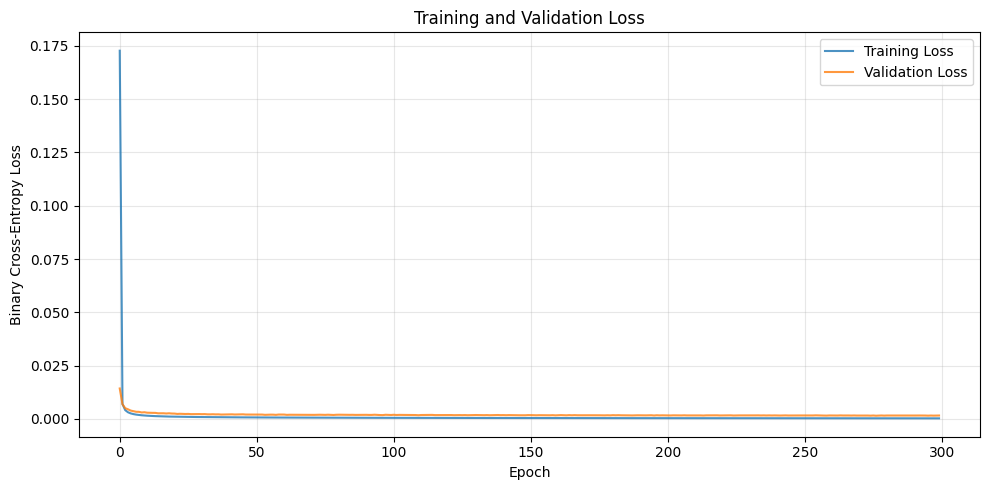

In [43]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', alpha=0.8)
plt.plot(val_losses, label='Validation Loss', alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Report the accuracy of your classifier on your validation dataset

In [44]:
# get predictions on the validation set
y_val_pred = nn.predict(X_val) 

# Threshold at 0.5 to get binary predictions
y_val_binary = (y_val_pred.T >= 0.5).astype(int)  

# calc accuracy
accuracy = np.mean(y_val_binary == y_val)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

# true positives, true negatives, false positives, false negatives
tp = np.sum((y_val_binary == 1) & (y_val == 1))
tn = np.sum((y_val_binary == 0) & (y_val == 0))
fp = np.sum((y_val_binary == 1) & (y_val == 0))
fn = np.sum((y_val_binary == 0) & (y_val == 1))

print(f"\nConfusion Matrix:")
print(f"  True Positives:  {tp}")
print(f"  True Negatives:  {tn}")
print(f"  False Positives: {fp}")
print(f"  False Negatives: {fn}")

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nPrecision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Validation Accuracy: 99.98%

Confusion Matrix:
  True Positives:  27
  True Negatives:  36651
  False Positives: 9
  False Negatives: 0

Precision: 0.7500
Recall:    1.0000
F1 Score:  0.8571


## Explain your choice of loss function and hyperparameters

| Choice | Value | Justification |
|--------|-------|---------------|
| **Loss function** | Binary Cross-Entropy (BCE) | BCE is a standard loss for binary classification. It measures the divergence between predicted probabilities and true labels, which should penalize confident wrong predictions. |
| **Output activation** | Sigmoid | The goal is to interpret the output as a probability. Since the sigmoid squishes the output to (0,1), it makes the mose sense. |
| **Hidden activations** | ReLU | ReLU avoids vanishing gradients in hidden layers and is computationally efficient. |
| **Architecture** | 68 - 64 - 32 - 1 | The input is 68 features (17 positions * 4). I chose 2 hidden layers of decreasing size in the hopes that the network might learn some hierarchical patterns. |
| **Learning rate** | 0.01 | Moderate learning rate to strike a balance between convergence speed and stability. |
| **Batch size** | 128 | this is a larger dataset than the auotoencoder dataset, so i chose a larger batch size. But same overall justification: smaller batches lead to more noise in gradient estimates and larger batches might cover the whole training set in one step. |
| **Epochs** | 300 | When testing different values, this provided enough training iterations for the loss to converge/plateau. |